# Computing volcano detection probabilities from a balloon platform
The code computes the probability of observing a signal with SNR > threshold at a given location or along a balloon trajectory for a variety of seismicity scenarios.

## Building detection maps

In [1]:
%matplotlib widget
from importlib import reload
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import geopandas as gpd

import sys
#sys.path.append('/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability')
import proba_modules as pm
reload(pm)

<module 'proba_modules' from '/staff/quentin/Documents/Projects/2025_Sophus_MSc/proba_modules.py'>

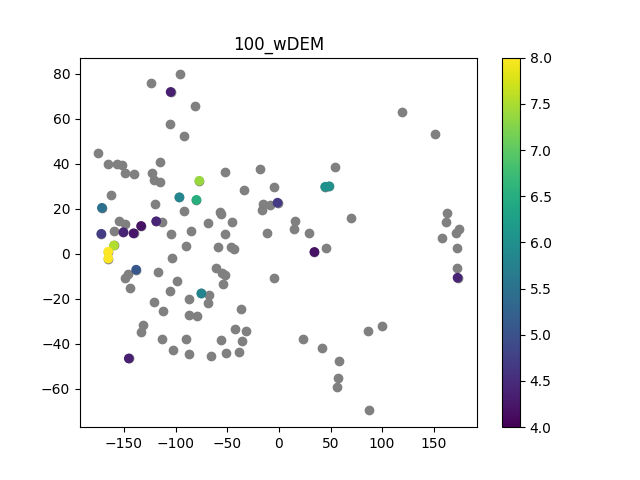

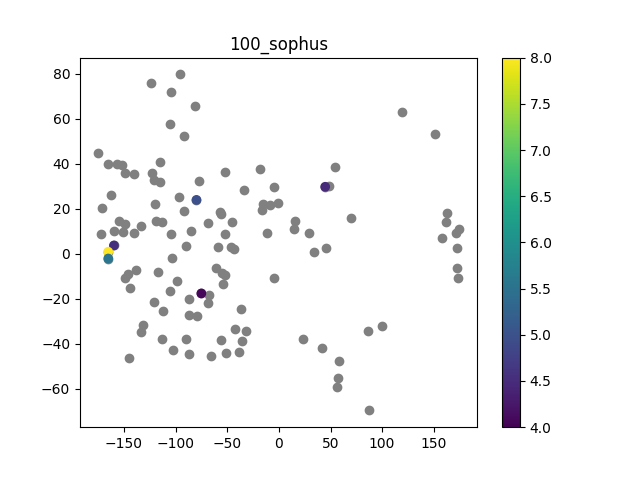

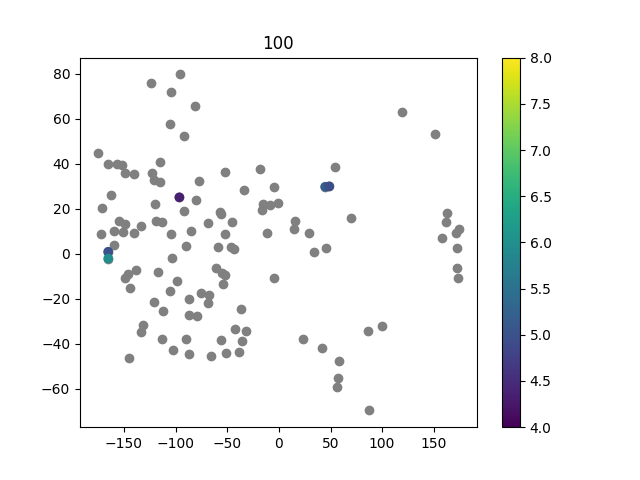

In [9]:
folder_volcano = '/staff/quentin/Documents/Projects/2025_Sophus_MSc/data_volcanoes/'
files_volcanoes=[(f'{folder_volcano}05_large_greaterthan100_wDEM.csv', 'Ellipse_Max_Altitude_km'),  (f'{folder_volcano}05_large_greaterthan100_sophus.csv', 'Topo'),  (f'{folder_volcano}05_large_greaterthan100.csv', 'Height_km')]

for file, col in files_volcanoes:
    data = pd.read_csv(file)
    plt.figure()
    val = data[col]
    if col == 'Topo':
        val /= 1e3
    plt.scatter(data.Lon_Center, data.Lat_Center, c='grey')
    mask = val.values>=4
    sc = plt.scatter(data.Lon_Center.values[mask], data.Lat_Center.values[mask], c=val.values[mask], vmin=4, vmax=8)
    plt.colorbar(sc)
    plt.title(file.split('greaterthan')[-1].split('.csv')[0])

In [2]:
reload(pm)

cols = ['Lat_Center', 'Lon_Center', 'Height_km', 'mean_gaussian', 'std_gaussian', 'n_eruptions_year', 'std_n_eruptions_year', 'type_v']
folder_volcano = '/staff/quentin/Documents/Projects/2025_Sophus_MSc/data_volcanoes/'
files_volcanoes=[f'{folder_volcano}05_large_greaterthan100_wDEM.csv',  ]
type_volcanoes = ['all',]
pd_volcanoes = pd.DataFrame()
for file, type_v in zip(files_volcanoes, type_volcanoes):
    pd_volcanoes_loc = pm.get_volcano_stats(file)
    pd_volcanoes_loc['type_v'] = type_v
    pd_volcanoes = pd.concat([pd_volcanoes, pd_volcanoes_loc.loc[:,pd_volcanoes_loc.columns.isin(cols)]])
pd_volcanoes.reset_index(drop=True, inplace=True)
pd_volcanoes.loc[pd_volcanoes['Height_km']>4].to_csv(f'{folder_volcano}05_large_greaterthan100_wDEM_Heightabove4km.csv', header=True, index=False)

In [ ]:
reload(pm)

start_locations=[[-85.,0.], [-45.,0.], [0.,0.], [45.,0.], [85.,0.]]

trajectory = []
for istart, start_location in enumerate(start_locations):
    opt_traj = dict(
        time_max=3600*24*30*6, ## in seconds
        start_location=start_location,
        alt_balloon=60., 
        file_atmos='/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/data/VCD_atmos_globe_new.dat'
    )
    trajectory.append( pm.compute_traj(**opt_traj) )

/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/VCD_trajectory_modules.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winds['gid'] = winds.groupby(['lat', 'lon'])['val'].transform('idxmin')
/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/VCD_trajectory_modules.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winds['wind_strength'] = winds.groupby(['lat', 'lon'])['val'].transform(lambda x: np.sqrt(sum(x**2)))
/staff/quentin/Documents/Pro

In [6]:
reload(pm)

opt_TL = dict(
    pattern_TL='balloon_tl_map_ust{}h_freq{}Hz_rangedep_60km.nc', 
    times_TL=np.arange(0,1),
    dropoff_hour_UST=1,
    folder_TL='/projects/restricted/infrasound/data/infrasound/2026_Venus_global_TLs/', 
)

folder_volcano = '/staff/quentin/Documents/Projects/2025_Sophus_MSc/data_volcanoes/'
scaling_Byrne_to_iris = 42/(4.14*6)
opt_volcanoes = dict(
    files_volcanoes=[#f'{folder_volcano}03_intermediate_5to100km.csv',
                     #f'{folder_volcano}04_all_greaterthan50km.csv',
                     f'{folder_volcano}05_large_greaterthan100_wDEM.csv', 
                     f'{folder_volcano}05_large_greaterthan100_wDEM_Heightabove4km.csv', 
                     ], 
    #n_eruptions_year=4.14*6, # original number from byrne
    #std_n_eruptions_year=2.13*6 # original number from byrne
    n_eruptions_year=4.14*6*scaling_Byrne_to_iris, # correction Iris
    std_n_eruptions_year=2.13*6*scaling_Byrne_to_iris # correction Iris
)

opt_amplitudes = dict(
    max_dist_linearfit = 19000., 
    min_dist_threshold_linearfit=1000.,
    dist_threshold_linearfit = 3000., 
    delta_dist = 1000.,
    perc_uncertainty = 1e-2,
    T_eruptions=[2.5], 
    #T_eruptions=[100.], 
    r_to_vent=1000., 
    #rho_surface=65., 
    perc_rise_to_duration=0.05,
    use_eruption_magnitudes=True,
    use_stf_amplitudes=True, 
)

opt_probas = dict(
    M0s = np.linspace(1., 7., 30), 
    SNR_thresholds = np.linspace(0.1, 10., 50), 
    noise_level = 1e-2, 
    duration = 1./(365.*24.), 
    m_min = 1., 
    r_venus = 6052, 
    which_TL_distribution='normal', 
    s_batch_volcanoes=5
)

opt_traj = dict(
    time_max=3600*24*30*6, ## in seconds
    start_locations=[[45.,0.]], # lat, lon
    #start_locations=[[-45.,0.],], # lat, lon
    alt_balloon=60., 
    file_atmos='/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/data/VCD_atmos_globe_new.dat',
    trajectory_df=pd.read_csv('./trajectories/trajectory_paths.csv', header=[0])
)

freqs = [0.5, 0.1, 0.05]
## Sensitivity test: lat drop off, alt balloon, snr, freqs, volcanoes
proba_models, trajectories = pm.get_all_probas(freqs, **opt_TL, **opt_volcanoes, **opt_amplitudes, **opt_probas, **opt_traj, folder_save_proba_map='/projects/restricted/infrasound/data/infrasound/2026_Venus_global_TLs/')

Overwriting drop off locations with trajectory_df DataFrame
t1= 0.14005804061889648
t2= 5.069169998168945
t3= 0.48364686965942383
Loading /projects/restricted/infrasound/data/infrasound/2026_Venus_global_TLs/probas_0.5Hz_2.5s_v0_0h.h5


100%|██████████| 3/3 [00:00<00:00, 155.38it/s]


t1= 0.1309056282043457
t2= 4.9290313720703125
t3= 0.481595516204834


100%|██████████| 3/3 [00:00<00:00, 166.66it/s]


t1= 0.13634634017944336
t2= 4.999953746795654
t3= 0.4816620349884033


100%|██████████| 3/3 [00:00<00:00, 172.89it/s]


In [5]:
trajectories.to_csv('./trajectories/trajectories_scaling.csv', header=True, index=False)

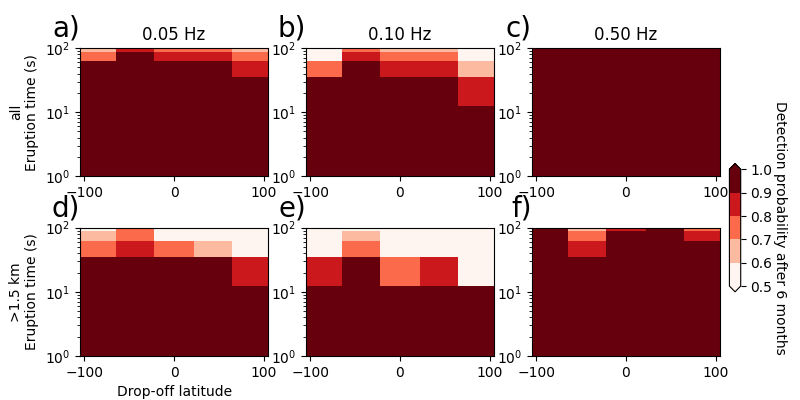

In [34]:
reload(pm)

n_months = 6
snr_chosen = 2
file = f'./figures/summary_Figure_scaling_{n_months}months.pdf'
file = None
pm.plot_Figure_summary(trajectories, opt_traj['start_locations'], n_months, snr_chosen, file=file)

./figures/summary_Figure_amplitude_model.pdf


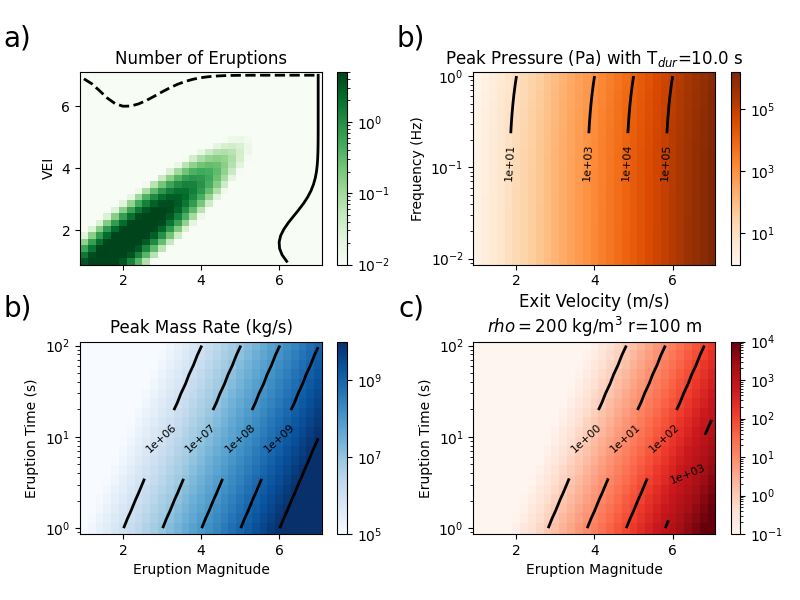

In [139]:
reload(pm)

file = f'./figures/summary_Figure_amplitude_model.pdf'
pm.plot_Figure_mass_rates(coef_rise_time=5e-2, rho_exit=200, radius=100, n_eruptions_year=24, file=file)

/staff/quentin/Documents/Projects/2025_Sophus_MSc/proba_modules.py:1965: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  type_v = labels_volcanoes[ivolcano_scatter]
/staff/quentin/Documents/Projects/2025_Sophus_MSc/proba_modules.py:1965: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  type_v = labels_volcanoes[ivolcano_scatter]
/staff/quentin/Documents/Projects/2025_Sophus_MSc/proba_modules.py:1965: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in 

./figures/Figure6_probas_traj_45N_50s.pdf


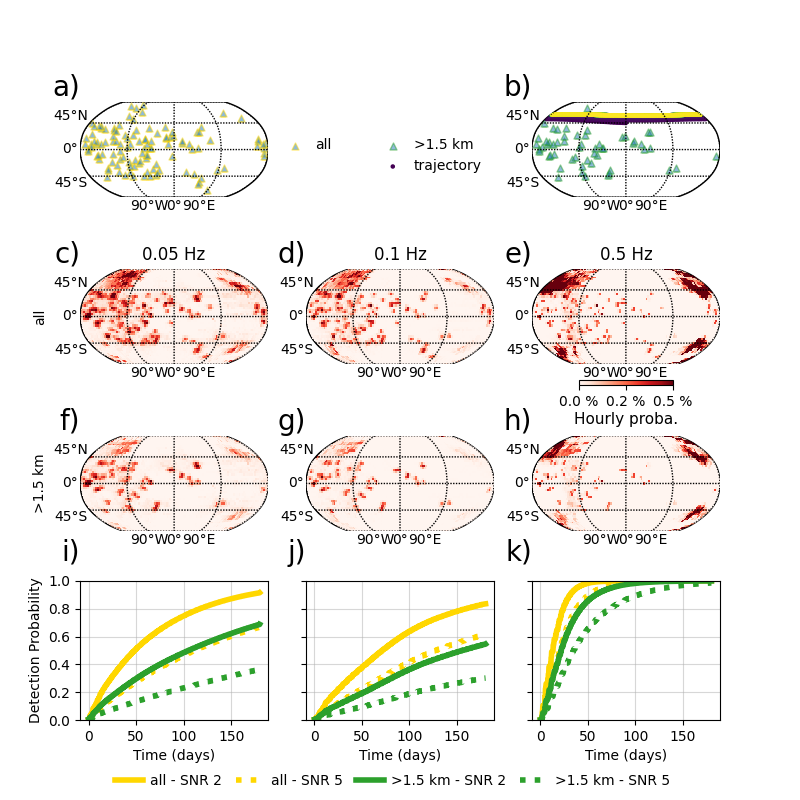

In [91]:
reload(pm)

opt_figure = dict(
    files_volcanoes= opt_volcanoes['files_volcanoes'], 
    snr_chosen=2., 
    other_snr_chosen=[5.],
    cmap='Reds', 
    n_hours=1, 
    vmax=5e-3, 
    vmin=0,
    labels_volcanoes = ['all', '>1.5 km',],
    mapping_ax = {0.05: 0, 0.1: 1, 0.5: 2},
    file='./figures/Figure6_probas_traj_45N_50s.pdf'
)
T_eruption = 50.
pm.plot_Figure_probas(proba_models[T_eruption], trajectories.loc[(trajectories.T_eruption==T_eruption)&(trajectories.istart==3)], **opt_figure)

## Test one proba map

In [4]:
import xarray as xr
reload(pm)

folder_volcano = '/staff/quentin/Documents/Projects/2025_Sophus_MSc/data_volcanoes/'
scaling_Byrne_to_iris = 42/(4.14*6)

opt_amplitudes = dict(
    max_dist_linearfit = 19000., 
    min_dist_threshold_linearfit=1000.,
    dist_threshold_linearfit = 3000., 
    delta_dist = 1000.,
    T_eruption= 50., 
    r_to_vent=1000., 
    perc_rise_to_duration=0.05,
    use_eruption_magnitudes=True,
    use_stf_amplitudes=True, 
)

opt_model = dict(
    M0s = np.linspace(1., 7., 30), 
    SNR_thresholds = np.linspace(0.1, 10., 50), 
    noise_level = 1e-2, 
    duration = 1./(365.*24.), 
    m_min = 1., 
    r_venus = 6052, 
    which_TL_distribution='normal', 
    s_batch_volcanoes=5
)

file_volcanoes = f'{folder_volcano}05_large_greaterthan100_wDEM_Heightabove4km.csv'
n_eruptions_year=4.14*6*scaling_Byrne_to_iris # correction Iris
std_n_eruptions_year=2.13*6*scaling_Byrne_to_iris # correction Iris
pd_volcanoes = pm.get_volcano_stats(file_volcanoes, n_eruptions_year=n_eruptions_year, std_n_eruptions_year=std_n_eruptions_year)

freq = 0.5
hour = 1
pattern_TL='balloon_tl_map_ust{}h_freq{}Hz_rangedep_60km.nc'
folder_TL='/projects/restricted/infrasound/data/infrasound/2026_Venus_global_TLs/'
pattern_loc = pattern_TL.format(f'{hour}', f'{freq:.3f}')
file_TL = f'{folder_TL}{pattern_loc}'
TL_data = xr.open_dataset(file_TL)
pd_amplitudes = pm.prepare_dataframe(TL_data)

t1= 0.1489560604095459
t2= 5.131182909011841
t3= 0.48402905464172363


In [10]:
reload(pm)

opt_amplitudes_map = opt_amplitudes.copy()
del opt_amplitudes_map['use_stf_amplitudes']
probas = pm.proba_model_stf(pd_volcanoes, pd_amplitudes, **opt_amplitudes_map, freq=freq)
probas.compute_proba_map(**opt_model)

Computing proba: 100%|██████████| 96/96 [00:27<00:00,  3.55it/s]


In [11]:
probas.save_h5("./test_model.h5")

In [12]:
model2 = pm.proba_model_stf.load_h5("./test_model.h5")

## Amplitude model

"\nax_2 = ax.twinx()\n#ax_2 = ax\nax_2.plot(VEIs, u_jet, color='red')\n#ax_2.set_xscale('log')\nax_2.set_yscale('log')\nax_2.set_ylabel('Jet velocity (m/s)', color='red')\nax_2.tick_params(axis='both', which='both', labelleft=False, left=False, labelright=True, labelcolor='red')\nax_2.set_ylim(ylim)\n\nax_3 = ax.twiny()\nax_3.plot(volumes, p, color='black')\nax_3.set_xscale('log')\nax_3.set_xlabel('Volume Erupted (m$^3$)')\n"

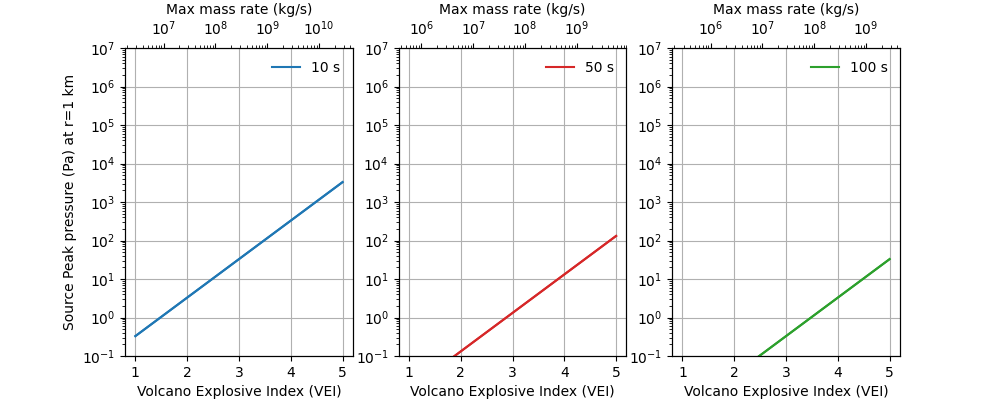

In [2]:
VEIs = np.arange(1, 6)
volumes = 10**(4.+VEIs)
K_m = 1
T = 100. # duration in s
#R = 100. # radius in m
r = 1000. # Distance from vent in m
rho = 65.
rho_exit = 300.
perc_rise_to_duration = 0.05
Ts = [10, 50, 100]
ylim = [1e-1, 1e7]

fig = plt.figure(figsize=(10,4))
grid = fig.add_gridspec(1, 3)
    
colors = ['tab:blue', 'tab:red', 'tab:green']
for ii, T in enumerate(Ts):
    
    ax = fig.add_subplot(grid[0, ii])
    #ax_3 = fig.add_subplot(grid[0, 1])
    ax_3 = ax.twiny()
    
    rise_time = perc_rise_to_duration*T
    M_max = rho_exit * volumes/(T+rise_time)
    #Omega_f = np.pi
    #u_jet = (volumes/(np.pi*T*R**2)) 
    #p = np.sqrt(np.pi*K_m/Omega_f) * (u_jet**2) * (R/r) * rho
    p = (1./(4*np.pi*r))*(1/(rise_time))*(rho/rho_exit)*(volumes/(T+rise_time))

    ax.plot(VEIs, p, label=f'{T:.0f} s', color=colors[ii])
    ax_3.plot(M_max, p, color=colors[ii])
    
    #plt.xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Volcano Explosive Index (VEI)')
    if ii == 0:
        ax.set_ylabel(f'Source Peak pressure (Pa) at r={r/1e3:.0f} km')
    ax.grid()
    ax.set_ylim(ylim)
    #ax.set_xlim([VEIs.min(), VEIs.max()])
    ax.legend(frameon=False)

    ax_3.set_xscale('log')
    #ax_3.set_xlabel(f'Max mass rate (kg/s) with duration $T={T:.0f}$s and rise time $T_r={rise_time:.0f}$s')
    ax_3.set_xlabel(f'Max mass rate (kg/s)')
    ax_3.set_ylim(ylim)
    ax_3.set_yscale('log')
    #ax_3.set_xlim([VEIs.min(), VEIs.max()])

"""
ax_2 = ax.twinx()
#ax_2 = ax
ax_2.plot(VEIs, u_jet, color='red')
#ax_2.set_xscale('log')
ax_2.set_yscale('log')
ax_2.set_ylabel('Jet velocity (m/s)', color='red')
ax_2.tick_params(axis='both', which='both', labelleft=False, left=False, labelright=True, labelcolor='red')
ax_2.set_ylim(ylim)

ax_3 = ax.twiny()
ax_3.plot(volumes, p, color='black')
ax_3.set_xscale('log')
ax_3.set_xlabel('Volume Erupted (m$^3$)')
"""

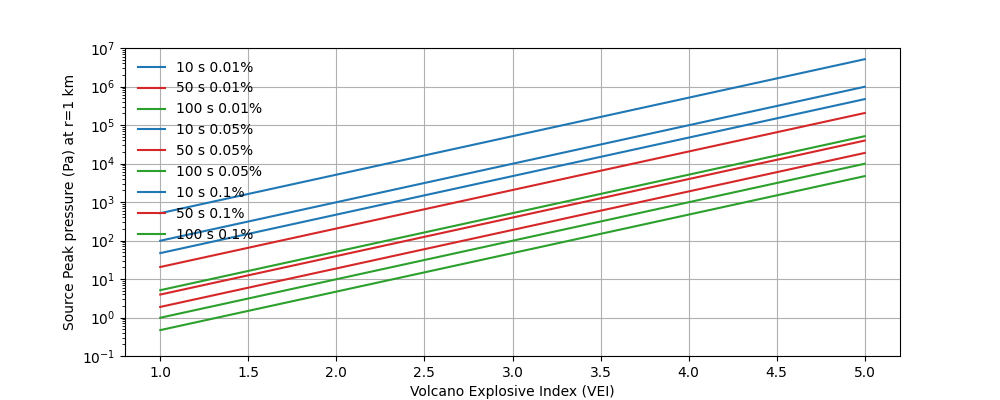

In [71]:
VEIs = np.arange(1, 6)
volumes = 10**(4.+VEIs)
K_m = 1
T = 100. # duration in s
#R = 100. # radius in m
r = 1000. # Distance from vent in m
rho = 65.
rho_exit = 10.
perc_rise_to_durations = [0.01, 0.05, 0.1]
Ts = [10, 50, 100]
ylim = [1e-1, 1e7]

fig = plt.figure(figsize=(10,4))
grid = fig.add_gridspec(1, 1)
ax = fig.add_subplot(grid[0, 0])
    
colors = ['tab:blue', 'tab:red', 'tab:green']
for jj, perc_rise_to_duration in enumerate(perc_rise_to_durations):
    for ii, T in enumerate(Ts):

        rise_time = perc_rise_to_duration*T
        M_max = rho_exit * volumes/(T+rise_time)
        p = (rho/(4*np.pi*r))*(1/(rise_time))*(volumes/(T+rise_time))

        ax.plot(VEIs, p, label=f'{T:.0f} s {perc_rise_to_duration}%', color=colors[ii])

        ax.set_yscale('log')
        ax.set_xlabel('Volcano Explosive Index (VEI)')
        if ii == 0:
            ax.set_ylabel(f'Source Peak pressure (Pa) at r={r/1e3:.0f} km')
        ax.grid()
        ax.set_ylim(ylim)
        ax.legend(frameon=False)

In [ ]:
import xarray as xr

file_TL = '/staff/quentin/Documents/Projects/2025_Sophus_MSc/data_TL/balloon_tl_map_ust12h_freq0.500Hz_rangedep.nc'
TL_data = xr.open_dataset(file_TL)

In [ ]:
reload(pm)
    
pd_amplitudes = pm.prepare_dataframe(TL_data)

## Eruption statistics

In [ ]:
from scipy.optimize import curve_fit
from scipy.special import erf

VEIs = np.arange(7)
probas = np.array([9.6, 36.8, 37.3, 13.6, 2.3, 0.3, 0.1])
n_eruptions_year = 4.14*6
std_n_eruptions_year = 2.13*6

def gaussian(x, mu, sigma):
    """A * exp(-((x - mu)^2) / (2 * sigma^2))"""
    return (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-((x - mu)**2) / (2 * sigma**2))

popt, pcov = curve_fit(gaussian, VEIs, probas*1e-2,)
x = np.linspace(VEIs.min(), VEIs.max(), 100)
mu_fit, sigma_fit = popt
p = gaussian(x, mu_fit, sigma_fit)

cdf_probas = np.cumsum(probas*1e-2)
cdf_p = 0.5*(1+erf((x-mu_fit)/(sigma_fit*np.sqrt(2))))

plt.figure()
plt.plot(VEIs, probas*1e-2*n_eruptions_year, label='Byrne')
#plt.plot(VEIs, n_eruptions_year-cdf_probas*n_eruptions_year)
#plt.plot(VEIs, probas*1e-2*(n_eruptions_year+std_n_eruptions_year))
plt.plot(x, p*n_eruptions_year, label='fit')
#plt.plot(x, n_eruptions_year-cdf_p*n_eruptions_year, ls=':')
#plt.plot(x, p*(n_eruptions_year+std_n_eruptions_year), ls=':')
plt.legend(frameon=False)
plt.grid()
plt.xlabel('VEI')
plt.ylabel('Number of eruptions per year')

file_volcanoes = '/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/data/volcanoes/05_large_greaterthan100.csv'
pd_volcanoes = pd.read_csv(file_volcanoes, header=[0])
pd_volcanoes['mean_gaussian'] = mu_fit
pd_volcanoes['std_gaussian'] = sigma_fit
pd_volcanoes['n_eruptions_year'] = n_eruptions_year
pd_volcanoes['std_n_eruptions_year'] = std_n_eruptions_year

In [ ]:
reload(pm)

file_volcanoes = '/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/data/volcanoes/05_large_greaterthan100.csv'
pd_volcanoes = pm.get_volcano_stats(file_volcanoes, n_eruptions_year=4.14*6, std_n_eruptions_year=2.13*6)

### Compute probabilities

In [ ]:
reload(pm)

opt_model = dict(
    M0s = np.linspace(1., 7., 30), # Low discretization will lead to terrible not unit integrals
    SNR_thresholds = np.linspace(0.1, 10., 50),
    noise_level = 1e-2, # noise level in Pa
    duration = 1./(365.*24.), # (1/mission_duration)
    m_min = 1.,
    r_venus = 6052,
    which_TL_distribution='normal',
    #default_p_uncertainty=10,
    s_batch_volcanoes=5
)

opt_amplitudes = dict(
    max_dist_linearfit = 19000., 
    dist_threshold_linearfit = 500., 
    delta_dist = 1000.
)
#proba_model = pm.proba_model(pd_volcanoes, pd_amplitudes.loc[pd_amplitudes.height==0.], TL_array_provided=None)
proba_model = pm.proba_model(pd_volcanoes, pd_amplitudes, **opt_amplitudes, TL_array_provided=None)
#proba_model.compute_scores_across_CPUs(**opt_model)

In [ ]:
TL_array_provided = proba_model.TL_array, proba_model.lat_balloons_default, proba_model.lon_balloons_default 

In [ ]:
reload(pm)

opt_model = dict(
    M0s = np.linspace(1., 7., 30), # Low discretization will lead to terrible not unit integrals
    SNR_thresholds = np.linspace(0.1, 10., 50),
    noise_level = 1e-2, # noise level in Pa
    duration = 1./(365.*24.), # (1/mission_duration)
    m_min = 1.,
    r_venus = 6052,
    which_TL_distribution='normal',
    #default_p_uncertainty=10,
    s_batch_volcanoes=5
)

proba_model = pm.proba_model(pd_volcanoes, pd_amplitudes.loc[pd_amplitudes.height==0.], TL_array_provided=TL_array_provided)
proba_model.compute_proba_map(**opt_model)

In [ ]:
lats = proba_model.all_lats
lons = proba_model.all_lons
lon, lat = 150., 51.6
ilat,ilon = np.argmin(abs(lats-lat)), np.argmin(abs(lons-lon)) # 63.75, -37.5
VEI = 5
scaler = lambda TL, VEI: (10**(VEI-7))*10**(TL/20.)
plt.figure()
#sc = plt.scatter(pd_volcanoes.Lon_Center, pd_volcanoes.Lat_Center, c=scaler(TL_array_provided[0][ilat,ilon,:], VEI),)
sc = plt.scatter(pd_volcanoes.Lon_Center, pd_volcanoes.Lat_Center, c=TL_array_provided[0][ilat,ilon,:], vmin=-500., vmax=0.,)
plt.colorbar(sc)
plt.scatter(proba_model.lon_balloons_default[ilat, ilon], proba_model.lat_balloons_default[ilat, ilon], marker='x', c='red')
plt.title(f'{proba_model.lon_balloons_default[ilat, ilon]} | {proba_model.lat_balloons_default[ilat, ilon]}')

In [ ]:
plt.figure()

lons_c = proba_model.all_lons.copy()
lats_c = proba_model.all_lats.copy()
lons_c[lons_c>180] -= 360.
idx = np.argsort(lons_c)
sc = plt.pcolormesh(lons_c[idx], lats_c, proba_model.proba_all[0,:,idx].T, vmax=0.1)
plt.colorbar(sc)

In [ ]:
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import FuncFormatter

cmap = 'Reds'
n_hours = 100
snr_chosens = [1,2,5]
SNR_thresholds = np.linspace(0.1, 10., 50)

proba = 1-(1.-proba_model.proba_all)**n_hours
lons = proba_model.all_lons.copy()
lons[lons>180] -= 360
LONS, LATS = np.meshgrid(lons, proba_model.all_lats)
idx = lons.argsort()
LONS = LONS[:,idx]
LATS = LATS[:,idx]

fig = plt.figure(figsize=(10,4))
grid = fig.add_gridspec(1, len(snr_chosens))
vmax, vmin = 5e-1, 0
for ii, snr_chosen in enumerate(snr_chosens):
    isnr = np.argmin(abs(SNR_thresholds-snr_chosen))
    proba_test = proba[isnr,:,idx].T
    #print(proba_test)
    ax = fig.add_subplot(grid[0, ii])
    m = Basemap(projection='robin', lon_0=0, ax=ax)
    m.drawmeridians(np.linspace(-180., 180., 5), labels=[0, 0, 0, 1], fontsize=10,)
    m.drawparallels(np.linspace(-90., 90., 5), labels=[1, 0, 0, 0], fontsize=10,)
    x, y = m(LONS.ravel(), LATS.ravel())
    x, y = x.reshape(LONS.shape), y.reshape(LONS.shape)
    sc = m.pcolormesh(x, y, proba_test, cmap=cmap, vmax=vmax, vmin=vmin)
    
    m.scatter(pd_volcanoes.Lon_Center, pd_volcanoes.Lat_Center, marker='^', edgecolor='black', latlon=True, s=5, alpha=0.3)

    if ii == len(snr_chosens)-1:
        fmt = lambda x, pos: '{:.2f} %'.format(x*1e2) # 
        axins = inset_axes(ax, width="3%", height="100%", loc='lower left', bbox_to_anchor=(1.03, 0., 1, 1.), bbox_transform=ax.transAxes, borderpad=0)
        axins.tick_params(axis='both', which='both', labelbottom=False, labelleft=False, bottom=False, left=False)
        cbar = fig.colorbar(sc, format=FuncFormatter(fmt), cax=axins, orientation='vertical', extend='both', )
        cbar.set_label(f'{n_hours:.0f}h mission probability', rotation=270, labelpad=10, fontsize=11)

    ax.set_title(f'SNR {snr_chosen:.0f}')
        
fig.subplots_adjust(left=0.05, right=0.8)
#fig.savefig(f'./figures/proba_seismometer_{opt_model["noise_level"]:.2e}_{n_hours}h_{freq:.2f}Hz.pdf')

## Trajectories

In [ ]:
sys.path.append('/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability')
import VCD_trajectory_modules as VCD
from importlib import reload
reload(VCD)

In [ ]:
reload(VCD)
start_lon = 0.
dlon = 2.
trajectory = VCD.compute_trajectory_airglow(start_lon, dlon, velocity_imager=-0.32, time_max=3600*24)

#plt.figure()
#sc = plt.scatter(trajectory.lon, trajectory.lat, c=trajectory.time)
#plt.colorbar(sc)

In [ ]:
reload(VCD)

file_atmos = '/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/data/VCD_atmos_globe_new.dat'
alt_balloon = 60.
altitude = alt_balloon*1e3
winds = VCD.get_winds(file_atmos, altitude)

In [ ]:
reload(VCD)

start_location = [-45.,0.] # lat, lon
#start_location = [45.,0.] # lat, lon
#start_location = [85.,0.] # lat, lon
#start_location = [-45.,90.] # lat, lon
#start_location = [85., -6.6] # lat, lon
opt_trajectory = dict(
    time_max=3600*24*30*2,
    save_trajectory=False,
    folder = './data/',
)
trajectory = VCD.compute_trajectory(winds, start_location, **opt_trajectory)

#file = './data/trajectory_balloon_lat0.00_lon0.00_15days.csv'
#file = './data/trajectory_balloon_lat50.00_lon50.00_15days.csv'
#trajectory = pd.read_csv(file, header=[0])

In [ ]:
trajectory

## Visualization

### Venusquakes - Map

In [ ]:
reload(pm)

PATH_VENUS_DATA = os.path.join("/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/data/")
PATH_VENUS = os.path.join(f"{PATH_VENUS_DATA}Venus_data/tectonic_settings_Venus")
VENUS = {
    'corona': gpd.read_file(f"{PATH_VENUS}/corona.shp"),
    'rift': gpd.read_file(f"{PATH_VENUS}/rifts.shp"),
    'ridge': gpd.read_file(f"{PATH_VENUS}/ridges.shp"),
}

opt_visualization = dict(
    VENUS = VENUS,
    c_cbar = 'black', 
    l_snr_to_plot = [1.,2.5], 
    n_colors = 10,
    plot_all_regions = False,
    use_active_corona = True
)

## active high
"""
opt_visualization.update(dict(
    low_cmap = np.arange(0.05, 0.35, 0.05), # 1 day RW low activity
    high_cmap = np.arange(0.6, 1.2, 0.1),))
"""
## active low
"""
opt_visualization.update(dict(
    low_cmap = np.arange(0.4, 0.6, 0.05), # 1 day RW low activity
    high_cmap = np.arange(0.6, 1.6, 0.1),))
"""

pm.plot_map(proba_model, **opt_visualization)

### Venusquakes - trajectories

In [ ]:
reload(pm)

snrs = proba_model.SNR_thresholds
lats, lons = proba_model.all_lats, proba_model.all_lons

####### WRINKLE RIDGES #######
#probas = proba_model_wrinkles.proba_all.copy()

####### TECTONIC #######
probas = proba_model.proba_all.copy() # SNR x lats x lons

## Checkout plot_P_over_k
#from scipy.stats import poisson
#probas = get_proba_from_more_events(probas, 3)

new_trajectories = pm.compute_proba_one_trajectory(trajectory, snrs, lats, lons, probas, norm_factor_time=3600.) ## Venusquakes
#new_trajectories = pm.compute_proba_one_trajectory(trajectory, proba_model_volcanoes, norm_factor_time=3600.) ## Volcanoes

In [ ]:
new_trajectories

In [ ]:
reload(pm)

opt_visualization = dict(
    VENUS=None,#pm.get_regions('../../../Venus_data/')
    snr=1., 
    n_colors=10, 
    c_cbar='black', 
    fontsize=15., 
    ylim=[0., 70.],
    plot_time=True,
    plot_volcanoes=False,
    n_colors_proba = 10, 
    n_colors_winds = 7,
    file = None
    #file='/staff/quentin/Documents/Projects/2024_Venus_Detectability/figures/Figure_2_balloon_proba_brune_1s.pdf'
    #file='/staff/quentin/Documents/Projects/2024_Venus_Detectability/figures/Figure_3_balloon_proba_1s_Hot40.pdf'
)

new_trajectories_total = new_trajectories.copy()
new_trajectories_total['seismicity'] = 'low'

####### WRINKLE RIDGES #######
#pm.plot_trajectory(new_trajectories_total, proba_model_wrinkles, winds, **opt_visualization)

####### TECTONIC #######
pm.plot_trajectory(new_trajectories_total, proba_model, winds, **opt_visualization)

## Figure manuscript

In [ ]:
def plot_volcano_TL_source_pressure_map(freq, source_pressure_grids):
    ds = xr.open_dataset(f"/Users/sophus/Documents/AIR/venus/global_tl_data/testing/balloon_tl_map_ust12h_freq{freq:.3f}Hz_rangedep_testing.nc")
    N = 1
    lons = ds.lon.values
    lats = ds.lat.values
    dlon = lons[1] - lons[0]
    dlat = lats[1] - lats[0]
    # lons = lons + dlon / 2
    # lats = lats + dlat / 2
    lons = np.append(lons, 180)
    lats = np.append(lats, 90)
    plot_config.set_plot_style(fig_width=6, fig_height=5, linewidth_frac=0.75)

    for SNR in [2]:
        grid = source_pressure_grids[SNR]
        LONS, LATS = np.meshgrid(lons, lats)
        fig = plt.figure()
        ax = fig.add_subplot(111, projection=ccrs.Robinson())
        
        vmax = 30000
        dlevel = 5000
        levels = np.arange(0, vmax + dlevel, dlevel)
        # cntf = ax.contourf(LONS, LATS, grid, levels=levels, cmap=cmc.batlow, vmin=None, vmax=vmax, transform=ccrs.PlateCarree(), extend='max')
        # cbar = plt.colorbar(cntf, ax=ax, pad=0.08, label=r"Source level [Pa]", shrink=0.75, orientation="horizontal")
        pcm = ax.pcolormesh(LONS, LATS, grid, cmap=cmc.batlow, vmin=None, vmax=vmax, transform=ccrs.PlateCarree(), rasterized=True)
        cbar = plt.colorbar(pcm, ax=ax, pad=0.08, label=r"Source level [Pa]", shrink=0.75, orientation="horizontal")
        
        volcano_csv_dir = "/Users/sophus/Documents/AIR/venus/venus_volcano_catalogue/CSV_updated"
        # small_volcanoes = pd.read_csv(os.path.join(volcano_csv_dir, "02_small_lessthan5km_lowres.csv"))
        # intermediate_volcanoes = pd.read_csv(os.path.join(volcano_csv_dir, "03_intermediate_5to100km.csv"))
        large_volcanoes = pd.read_csv(os.path.join(volcano_csv_dir, "05_large_greaterthan100.csv"))

        # s_lon, s_lat = small_volcanoes["Long"].to_numpy(), small_volcanoes["Lat"].to_numpy()
        # i_lon, i_lat = intermediate_volcanoes["Lon_Center"].to_numpy(), intermediate_volcanoes["Lat_Center"].to_numpy()
        l_lon, l_lat = large_volcanoes["Lon_Center"].to_numpy(), large_volcanoes["Lat_Center"].to_numpy()

        # scatter the volcanoes
        # ax.scatter(i_lon, i_lat, color='orange', s=5, label='Intermediate Volcanoes', transform=ccrs.PlateCarree(), marker='^')
        ax.scatter(l_lon, l_lat, color='red', s=10, label='Large Volcanoes', transform=ccrs.PlateCarree(), marker='^')

        gl = ax.gridlines(draw_labels=True, color="gray", alpha=0.05)
        gl.top_labels = False
        gl.right_labels = False

        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

        plt.show()

freq = 0.05
plot_volcano_TL_source_pressure_map(freq, source_pressure_grids)

## DEBUG

In [ ]:
from tqdm import tqdm

self.max_dist_linearfit = 19e3
self.dist_threshold_linearfit = 0.7e3
self = proba_model
g = Geod(ellps='WGS84')

#n_loc = self.pd_amplitudes.groupby(['lat', 'lon'])['TL'].first().reset_index().shape[0]
n_lat = self.pd_amplitudes.lat.unique().size
n_lon = self.pd_amplitudes.lon.unique().size
n_az = self.pd_amplitudes.az.unique().size
n_dist = self.pd_amplitudes.dist.unique().size
#dists_unique = self.pd_amplitudes.dist.unique()
n_height = self.pd_amplitudes.height.unique().size
shape_init = (n_az, n_dist, n_height) #(48, 96, 12, 300, 7)

self.lat_balloons_default = np.zeros((n_lat, n_lon))
self.lon_balloons_default = np.zeros((n_lat, n_lon))
self.TL_array = np.zeros((n_lat, n_lon, self.lat_volcanoes.size)) # lat x lon x dists
#self.TL_array = []

ilat = -1
for lat, pd_amplitudes_balloon_lat in tqdm(self.pd_amplitudes.groupby(['lat']), total=n_lat, desc='Preparing amplitudes'): ## Loop over balloon locations
    ilat += 1

    ilon = -1
    for lon, pd_amplitudes_balloon in pd_amplitudes_balloon_lat.groupby(['lon']): ## Loop over balloon locations
        
        
        diff_lat = abs(lat-(-37.5))<10.
        diff_lon = abs(lon-63.75)<10.
        #print(lon, lat, abs(lat-(-37.5)), abs(lon-63.75))
        if not (diff_lat and diff_lon):
            continue
        

        ilon += 1
        azimuths = pd_amplitudes_balloon.az.values.reshape(shape_init)
        dists = pd_amplitudes_balloon.dist.values.reshape(shape_init)
        TL_loc = pd_amplitudes_balloon.TL.values.reshape(shape_init)
        heights = pd_amplitudes_balloon.height.values.reshape(shape_init)

        dist_extrapolation = np.arange(dists.min()+self.delta_dist, self.max_dist_linearfit, self.delta_dist)
        s_extrapolation = dist_extrapolation.size
        idx = dists[0,:,0] > self.dist_threshold_linearfit
        def _fit_1d(y):
            coeffs = np.polyfit(dists[0,idx,0], y, 1)  # degree 1 = linear
            return coeffs[0]*dist_extrapolation + coeffs[1]

        TL_new = np.apply_along_axis(_fit_1d, 1, TL_loc[:,idx,:])
        TL_loc = np.concatenate((TL_loc[:,~idx,:], TL_new), axis=1)

        def expand_to_all_axes(unknown, axis):
            new_shape = ()
            new_shape_output = ()
            for ishape, shape in enumerate(TL_new.shape):
                if ishape == axis:
                    new_shape += (1,)
                    new_shape_output += (unknown.size,)
                else:
                    new_shape += (shape,)
                    new_shape_output += (1,)
            unknown_expanded = unknown.reshape(new_shape_output)
            return np.tile(unknown_expanded, new_shape)

        dist_extrapolation = expand_to_all_axes(dist_extrapolation, 1)
        dists = np.concatenate((dists[:,~idx,:], dist_extrapolation), axis=1)
        azimuths = np.concatenate((azimuths[:,~idx,:], np.repeat(azimuths[:,0:1,:], s_extrapolation, axis=1)), axis=1)
        heights = np.concatenate((heights[:,~idx,:], np.repeat(heights[:,0:1,:], s_extrapolation, axis=1)), axis=1)

        #shape_init = azimuths.shape
        azimuths, dists, TL_loc, heights = azimuths.ravel(), dists.ravel(), TL_loc.ravel(), heights.ravel()
        
        """
        fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
        sc = ax.scatter(np.radians(azimuths), dists, c=TL_loc, vmin=-400., vmax=0.)
        plt.colorbar(sc)
        """

        endlon, endlat, _ = g.fwd(lon+np.zeros_like(azimuths), lat+np.zeros_like(azimuths), azimuths, dists*1e3)
        
        id_TL, id_volcanoes = np.meshgrid(np.arange(azimuths.size), np.arange(self.lat_volcanoes.size)) # dists x n_points_TL

        idx_closest_TL = np.sqrt((endlon[id_TL]-self.lon_volcanoes[id_volcanoes])**2+(endlat[id_TL]-self.lat_volcanoes[id_volcanoes])**2)
        idx_furthest_H = abs(self.height_volcanoes[id_volcanoes]-heights[id_TL])>20
        idx_closest_TL[idx_furthest_H] += 1e6
        idx_closest_TL = idx_closest_TL.argmin(axis=1)
        #print(idx_closest_TL.shape, idx_closest_H.shape)

        fig, ax = plt.subplots()
        sc = ax.scatter(endlon, endlat, c=TL_loc, vmin=-400., vmax=0.)
        plt.colorbar(sc)
        plt.scatter(self.lon_volcanoes, self.lat_volcanoes, marker='^', c=TL_loc[idx_closest_TL], vmin=-400., vmax=0., edgecolor='black')
        plt.scatter(lon, lat, c='red', marker='o', s=200)
        
        self.TL_array[ilat, ilon,:] = TL_loc[idx_closest_TL]

        self.lat_balloons_default[ilat, ilon] = lat
        self.lon_balloons_default[ilat, ilon] = lon
        
        break

    #break
        
#self.TL_array = np.array(self.TL_array).T # dists x loc
#self.lat_balloons_default = np.array(self.lat_balloons_default) # dists 
#self.lon_balloons_default = np.array(self.lon_balloons_default) # dists 